In [349]:
import pandas as pd
import numpy as np
#from IPython.display import HTML
year = 2024
TARGET_STATE = "IA"

#['WI', 'MN', 'IA', 'IL', 'MI']

In [350]:
miso_plants_renewable = pd.read_excel("merged_miso_renew_eia923_" + str(year) + ".xlsx")

In [351]:
# Filter to target state
#for TARGET_STATE in TARGET_STATES:    
#    state_df_solar = miso_plants_renewable[(miso_plants_renewable["State"] == TARGET_STATE) & (miso_plants_renewable["Prime Mover"] == "PV")]
#    state_df_wind = miso_plants_renewable[(miso_plants_renewable["State"] == TARGET_STATE) & (miso_plants_renewable["Prime Mover"] == "WT")]
#
#    # Export to Excel
#    if not state_df_solar.empty:
#        state_df_solar.to_excel(f"miso_renewable_{TARGET_STATE}_{year}_solar.xlsx", index=False)
#    if not state_df_wind.empty:
#        state_df_wind.to_excel(f"miso_renewable_{TARGET_STATE}_{year}_wind.xlsx", index=False)
#        
#    print(f"Exported {len(state_df_solar)} rows for {TARGET_STATE}")
#    print(f"Exported {len(state_df_wind)} rows for {TARGET_STATE}")

In [352]:
wind_coords_list = []
solar_coords_list = []

for i in range(len(miso_plants_renewable)):
    
    ## Skip if not the target state
    #if miso_plants_renewable["State"].iloc[i] != TARGET_STATE:
    #    continue
    
    lat = miso_plants_renewable["Latitude"].iloc[i]
    lon = miso_plants_renewable["Longitude"].iloc[i]
    name = miso_plants_renewable["Plant Name"].iloc[i]
    EIA_ID = miso_plants_renewable["Plant Code"].iloc[i]

    item = {"lat": lat, "lon": lon, "label": name, "EIA_ID": EIA_ID,}

    if miso_plants_renewable["Prime Mover"].iloc[i] == "WT":
        wind_coords_list.append(item)
    elif miso_plants_renewable["Prime Mover"].iloc[i] == "PV":
        solar_coords_list.append(item)

#print("Wind coordinates:", wind_coords_list)
#print("Solar coordinates:", solar_coords_list)

wind_eia_ids = [c["EIA_ID"] for c in wind_coords_list]
solar_eia_ids = [c["EIA_ID"] for c in solar_coords_list]

print("Wind EIA IDs:", wind_eia_ids)
print("Solar EIA IDs:", solar_eia_ids)

Wind EIA IDs: [944, 1172, 1998, 2022, 2024, 7886, 54793, 55208, 55265, 55287, 55342, 55353, 55354, 55561, 55562, 55563, 55564, 55565, 55566, 55567, 55568, 55569, 55570, 55571, 55572, 55573, 55574, 55576, 55742, 55782, 55804, 55809, 55816, 56002, 56010, 56054, 56099, 56172, 56174, 56199, 56200, 56201, 56202, 56203, 56204, 56205, 56206, 56207, 56208, 56209, 56210, 56251, 56252, 56296, 56307, 56347, 56355, 56357, 56379, 56383, 56386, 56391, 56392, 56408, 56409, 56410, 56411, 56412, 56413, 56414, 56415, 56416, 56424, 56459, 56494, 56501, 56543, 56544, 56573, 56577, 56580, 56581, 56586, 56587, 56588, 56589, 56590, 56605, 56617, 56626, 56630, 56635, 56647, 56659, 56669, 56670, 56677, 56679, 56750, 56755, 56764, 56765, 56767, 56782, 56792, 56793, 56794, 56797, 56809, 56810, 56811, 56824, 56825, 56826, 56827, 56828, 56831, 56840, 56856, 56860, 56876, 56912, 56913, 56919, 56923, 56924, 56925, 56942, 56994, 57031, 57032, 57033, 57038, 57047, 57048, 57097, 57111, 57116, 57120, 57121, 57131, 57171

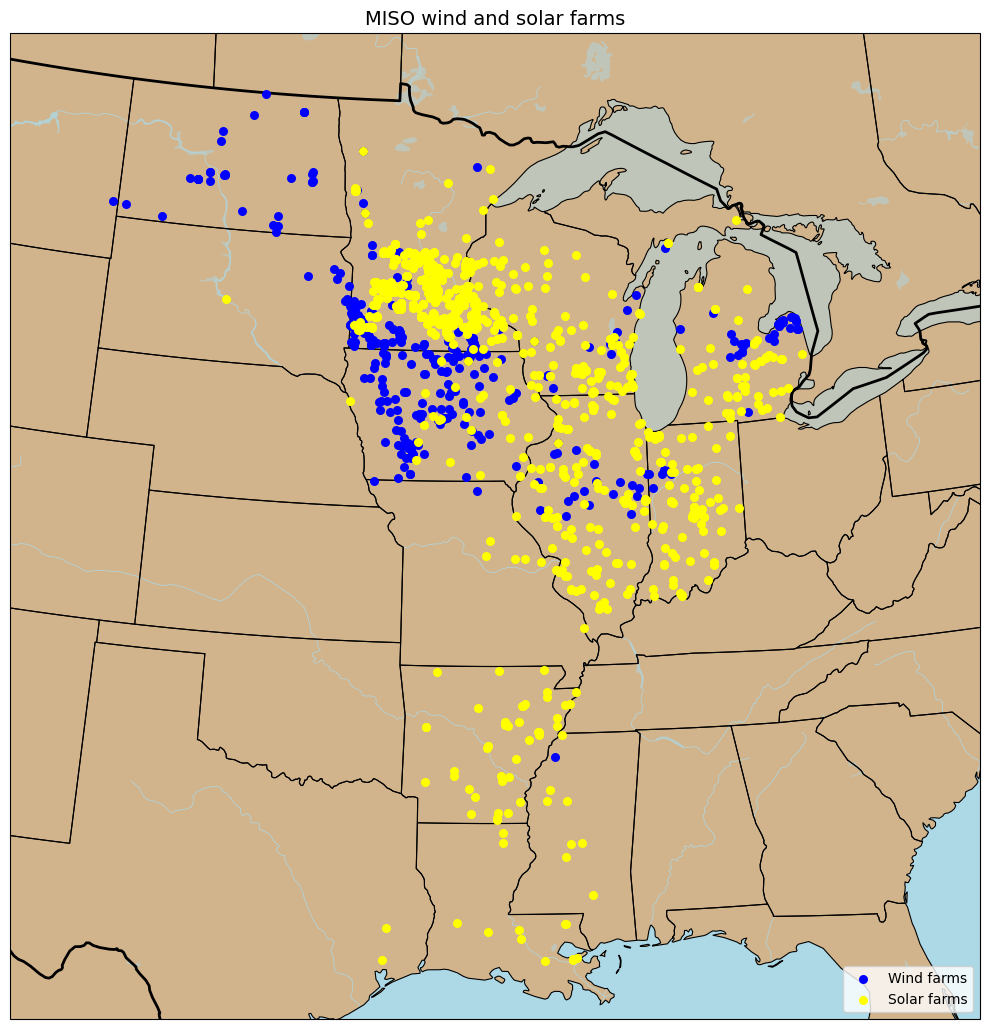

In [353]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- Your coordinates with custom labels ---
wind_coords = wind_coords_list   # Use the wind_coords list created earlier
solar_coords = solar_coords_list  # Use the solar_coords list created earlier

# --- MISO region bounds ---
WEST, EAST   = -104, -80
SOUTH, NORTH =   28, 50

fig, ax = plt.subplots(
    figsize=(10, 12),
    subplot_kw={"projection": ccrs.LambertConformal(
        central_longitude=-92,
        central_latitude=40
    )}
)

ax.set_extent([WEST, EAST, SOUTH, NORTH], crs=ccrs.PlateCarree())

# --- Map features ---
ax.add_feature(cfeature.LAND,    facecolor="tan")
ax.add_feature(cfeature.OCEAN,   facecolor="lightblue")
ax.add_feature(cfeature.LAKES,   facecolor="lightblue", alpha=0.5)
ax.add_feature(cfeature.RIVERS,  edgecolor="lightblue", linewidth=0.5)
ax.add_feature(cfeature.STATES,  edgecolor="black",     linewidth=0.8)
ax.add_feature(cfeature.BORDERS, edgecolor="black",     linewidth=2)

# --- Extract lists from coords ---
wind_lats   = [c["lat"]   for c in wind_coords]
wind_lons   = [c["lon"]   for c in wind_coords]
wind_labels = [c["label"] for c in wind_coords]

solar_lats   = [c["lat"]   for c in solar_coords]
solar_lons   = [c["lon"]   for c in solar_coords]
solar_labels = [c["label"] for c in solar_coords]

# --- Plot points ---
ax.scatter(
    wind_lons, wind_lats,
    transform=ccrs.PlateCarree(),
    color="blue",
    s=30,
    zorder=5,
    label="Wind farms"
)

ax.scatter(
    solar_lons, solar_lats,
    transform=ccrs.PlateCarree(),
    color="yellow",
    s=30,
    zorder=5,
    label="Solar farms"
)

## --- Plot labels ---
#for lat, lon, label in zip(old_lats, old_lons, old_labels):
#    ax.text(
#        lon + 0.3, lat + 0.3,
#        transform=ccrs.PlateCarree(),
#        fontsize=8,
#        fontweight="bold",
#        color="black",
#        bbox=dict(
#            facecolor="white",
#            alpha=0.6,
#            edgecolor="none",
#            boxstyle="round,pad=0.2"
#        )
#    )

ax.set_title("MISO wind and solar farms", fontsize=14)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()